In [1]:
import matplotlib.pyplot as plt
import numpy as np

# LU decomposition

In [2]:
def LUdecomposition(mat):
    # n is the size of the matrix
    n = len(mat)

    # lower and upper matrices
    lower = [[0 for x in range(n)] for y in range(n)]
    upper = [[0 for x in range(n)] for y in range(n)]

    for i in range(n):

        #for the upper matrix
        for k in range(i, n):

            sum = 0
            for j in range(i):
                sum += (lower[i][j] * upper[j][k])

            upper[i][k] = mat[i][k] - sum

        #for the lower matrix
    
        for k in range(i, n):
            if (i == k):
                lower[i][i] = 1

            else:
                sum = 0
                for j in range(i):
                    sum += (lower[k][j] * upper[j][i])

                lower[k][i] = (mat[k][i] - sum) / upper[i][i]

    return lower, upper

# Computing the inverse of a matrix using LU decomposition

In [3]:
# the forward substitution function
def forward_substitution(lower, b):
    n = len(lower)
    y = [0 for i in range(n)]
    y[0] = b[0] / lower[0][0]
    for i in range(1, n):
        sum = 0
        for j in range(i):
            sum += lower[i][j] * y[j]
        y[i] = (b[i] - sum) / lower[i][i]
    return y

# the backward substitution function
def backward_substitution(upper, y):
    n = len(upper)
    x = [0 for i in range(n)]
    x[n-1] = y[n-1] / upper[n-1][n-1]
    for i in range(n-2, -1, -1):
        sum = 0
        for j in range(i+1, n):
            sum += upper[i][j] * x[j]
            x[i] = (y[i] - sum) / upper[i][i]
    return x


def inverse(mat):
    n = len(mat)
    inv = [[0 for x in range(n)] for y in range(n)]

    # Perform LU decomposition
    lower, upper = LUdecomposition(mat)

    for i in range(n):
        # Identity matrix column
        identity = [0 for x in range(n)]
        identity[i] = 1

        # Solve Ly = b
        y = forward_substitution(lower, identity)

        # Solve Ux = y
        x = backward_substitution(upper, y)

        for j in range(n):
            inv[j][i] = x[j]

    return inv




# Visualization function

In [4]:
def visualize(X, Y, theta, n):
    
    plt.figure(figsize=(10, 6))

    # Plotting the data points
    plt.scatter(X, Y, color='blue', label='Data points')

    # Plotting the best fitting curve
    x_range = np.linspace(min(X), max(X), 500)
    y_range = []
    for x in x_range:
        prediction = 0
        for j in range(n):
            prediction += theta[j] * (x ** j)
        y_range.append(prediction)
    
    plt.plot(x_range, y_range, color='red', label='Fitting curve')

    # Labels and title
    plt.xlabel('X')
    plt.ylabel('Y')
    
    plt.legend()
    plt.grid(True)
    plt.show()

# LSE function

In [5]:



# input : The path and name of a file which consists of data points (comma seperated: x,y)
# input : The number of polynomial bases n
# input : lambda

def LSE(path, n, lam):

    # reading the file and creating two sets X and Y containing the data points
    X = []
    Y = []
    with open(path, 'r') as f:
        for line in f:
            x, y = line.split(',')
            X.append(float(x))
            Y.append(float(y))



    # using these two sets we create the design matrix A
    A = []
    for i in range(len(X)):
        row = []
        for j in range(n):
            row.append(X[i]**j)
        A.append(row)

   

    # computing AT
    AT = []
    for i in range(n):
        row = []
        for j in range(len(X)):
            row.append(A[j][i])
        AT.append(row)

    

    # Initialize ATA matrix
    m = len(AT)
    ATA = [[0 for _ in range(m)] for _ in range(m)]

    # Compute ATA
    for i in range(m):
        for j in range(m):
            sum = 0
            for k in range(len(A)):
                sum += AT[i][k] * A[k][j]
            ATA[i][j] = sum



    

    # Adding lambda*I to ATA
    ATAlam = [[ATA[i][j] + (lam if i == j else 0) for j in range(len(ATA[0]))] for i in range(len(ATA))]



    

    # the inverse of ATAlam
    ATAlamInv = inverse(ATAlam)

    

    # Compute A^T * Y
    AT_Y = []
    for i in range(n):
        sum = 0
        for j in range(len(Y)):
            sum += AT[i][j] * Y[j]
        AT_Y.append(sum)


   

    # Compute theta = (A^T A + lambda * I)^-1 * (A^T * Y)
    theta = []
    for i in range(n):
        sum = 0
        for j in range(n):
            sum += ATAlamInv[i][j] * AT_Y[j]
        theta.append(sum)

    


   # Print out the equation of the best fitting polynomial
    print("Best fitting polynomial equation:")
    equation = " + ".join(f"{theta[i]:.2f}*x^{i}" for i in range(n))
    print(f"y = {equation}")

    # Compute predictions and error
    predictions = []
    for x in X:
        prediction = 0
        for j in range(n ):
            prediction += theta[j] * (x ** j)
        predictions.append(prediction)

    error_sum = 0
    for i in range(len(Y)):
        error_sum += (Y[i] - predictions[i]) ** 2

    mse = error_sum

    print("Mean Squared Error (MSE):")
    print(f"{mse:.2f}")

   
    # Visualization
    visualize(X, Y, theta, n)




Best fitting polynomial equation:
y = 0.05*x^0 + 0.09*x^1 + 0.83*x^2
Mean Squared Error (MSE):
22649.74


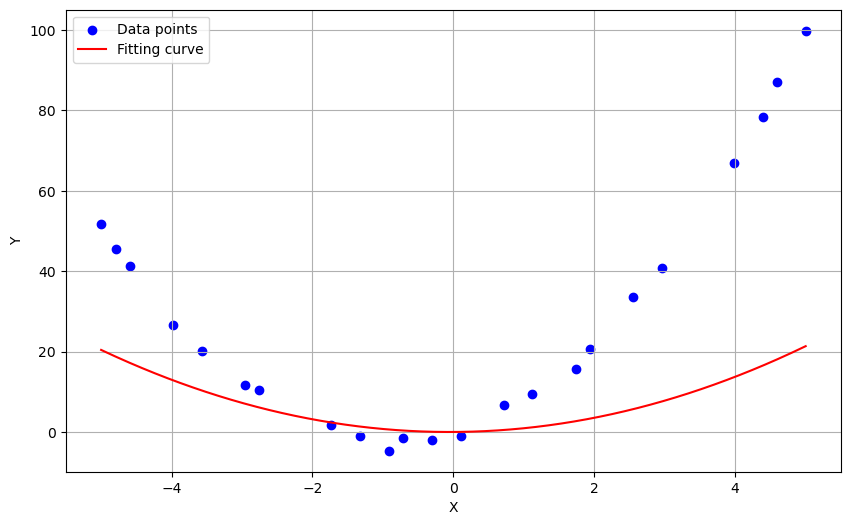

In [15]:
# testing
LSE('testfile.txt', 3, 10000)

# **steepest descent method**

In [9]:


# Implementing the steepest descent function
def steepestDescent(path, n):

    # Initialization of theta vector: size = n
    theta = [0] * n  # theta vector with zeros

    # Convergence tolerance
    epsilon = 0.000001

    # Maximum number of iterations
    max_iterations = 10000

    # Learning rate
    alpha = 0.0001

    # Reading the file and creating two sets X and Y containing the data points
    X = []
    Y = []
    with open(path, 'r') as f:
        for line in f:
            x, y = line.split(',')
            X.append(float(x))
            Y.append(float(y))

    # Using these two sets, we create the design matrix A
    A = []
    for i in range(len(X)):
        row = []
        for j in range(n):
            row.append(X[i]**j)
        A.append(row)

  

    # Computing AT (transpose of A)
    AT = []
    for i in range(n):
        row = []
        for j in range(len(X)):
            row.append(A[j][i])
        AT.append(row)

    

    previous_theta = theta.copy()  # For storing previous theta values

    # For each iteration, compute the gradient of the cost function
    for i in range(max_iterations):

        # Compute the gradient of the cost function with L1 regularization
        gradient = []
        for j in range(n):
            sum = 0
            for k in range(len(X)):
                dot_product = 0
                for i in range(len(theta)):
                    dot_product += A[k][i] * theta[i]

                sum += (dot_product - Y[k]) * A[k][j]

            gradient.append(sum)

        # Update the parameters theta
        for j in range(n):
            theta[j] = theta[j] - alpha * gradient[j]

        # Check for convergence using the absolute difference
        convergence = True
        for j in range(n):
            if abs(theta[j] - previous_theta[j]) >= epsilon:
                convergence = False
                break

        if convergence:
            print(f"Converged in {i} iterations")
            break

        # Update previous_theta for the next iteration
        previous_theta = theta.copy()

    #
    # Print out the equation of the best fitting polynomial
    print("Best fitting polynomial equation:")
    equation = " + ".join(f"{theta[i]:.2f}*x^{i}" for i in range(n))
    print(f"y = {equation}")

    # Compute predictions and error
    predictions = []
    for x in X:
        prediction = 0
        for j in range(n):
            prediction += theta[j] * (x ** j)
        predictions.append(prediction)

    error_sum = 0
    for i in range(len(Y)):
        error_sum += (Y[i] - predictions[i]) ** 2

    mse = error_sum
    print("Mean Squared Error (MSE):")
    print(f"{mse:.2f}")

    # Visualization

    visualize(X, Y, theta, n)



Converged in 2 iterations
Best fitting polynomial equation:
y = -0.23*x^0 + 4.91*x^1 + 3.02*x^2
Mean Squared Error (MSE):
26.56


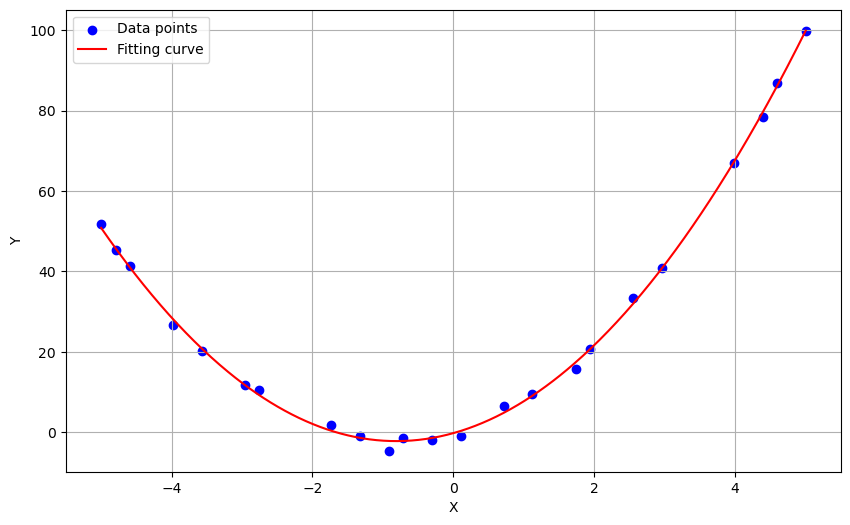

In [10]:
steepestDescent('testfile.txt', 3)

# **Newton's method**

In [11]:

# newton's method

def newton_method(path, n):

    # reading the file
    X = []
    Y = []
    with open(path, 'r') as f:
        for line in f:
            x, y = line.split(',')
            X.append(float(x))
            Y.append(float(y))

    # initializing theta
    theta = [0] * n

    # convergence tolerance
    epsilon = 0.0001

    # maximum number of iterations
    max_iterations = 10000

    # Using these two sets, we create the design matrix A
    A = []
    for i in range(len(X)):
        row = []
        for j in range(n):
            row.append(X[i]**j)
        A.append(row)

   
    # Computing AT (transpose of A)
    AT = []
    for i in range(n):
        row = []
        for j in range(len(X)):
            row.append(A[j][i])
        AT.append(row)

    

    # computing the hessian matrix H = ATA
    H = []
    for i in range(n):
        row = []
        for j in range(n):
            sum = 0
            for k in range(len(X)):
                sum += A[k][i] * A[k][j]


            row.append(sum)
        H.append(row)

   

    # computing the inverse of H
    Hinv = inverse(H)

   

    previous_theta = theta.copy()

    for i in range(max_iterations):
        # Compute the gradient of the cost function with L1 regularization
        gradient = []
        for j in range(n):
            sum = 0
            for k in range(len(X)):
                dot_product = 0
                for i in range(len(theta)):
                    dot_product += A[k][i] * theta[i]

                sum += (dot_product - Y[k]) * A[k][j]

            gradient.append(sum)

        # Update the parameters theta
        update = [0] * n
        for j in range(n):
            for k in range(n):
                update[j] += Hinv[j][k] * gradient[k]

        for j in range(n):
            theta[j] -= update[j]

        # Check for convergence using the absolute difference
        convergence = True
        for j in range(n):
            if abs(theta[j] - previous_theta[j]) >= epsilon:
                convergence = False
                break

        if convergence:
            print(f"Converged in {i} iterations")
            break

        # Update previous_theta for the next iteration
        previous_theta = theta.copy()


    # Print out the equation of the best fitting polynomial
    print("Best fitting polynomial equation:")
    equation = " + ".join(f"{theta[i]:.2f}*x^{i}" for i in range(n))
    print(f"y = {equation}")

    # Compute predictions and error
    predictions = []
    for x in X:
        prediction = 0
        for j in range(n):
            prediction += theta[j] * (x ** j)
        predictions.append(prediction)

    error_sum = 0
    for i in range(len(Y)):
        error_sum += (Y[i] - predictions[i]) ** 2

    mse = error_sum
    print("Mean Squared Error (MSE):")
    print(f"{mse:.2f}")

    
    # Visualization
    visualize(X, Y, theta, n)


Converged in 2 iterations
Best fitting polynomial equation:
y = -0.23*x^0 + 4.91*x^1 + 3.02*x^2
Mean Squared Error (MSE):
26.56


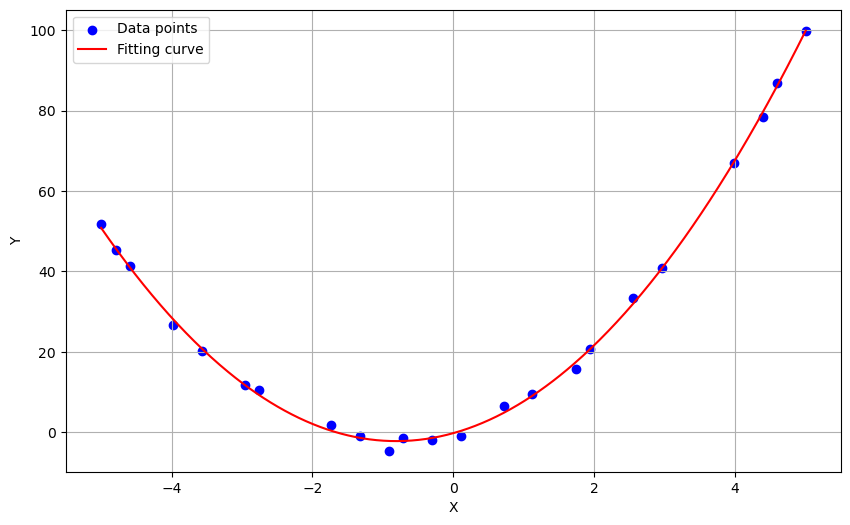

In [12]:
newton_method('testfile.txt', 3)